In [ ]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr
import arviz as az
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
#jax.config.update("jax_enable_x64", True)

num_dimensions = 50
num_data = 100
noise_magnitude_on_each_point = 0.1
total_length = 1
def matern_32(r, variance=1.0, scale=total_length/5, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_dimensions - 1)

fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
shape = (num_dimensions, num_dimensions)
dist_matrix = jnp.fromfunction(dist_function, shape)
cov_prior_matrix = matern_32(dist_matrix)
inv_cov_prior_matrix = jnp.linalg.inv(cov_prior_matrix)


diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)


#observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)
#R = jnp.zeros((num_data, num_dimensions));
#R = R.at[jnp.arange(num_data), observed_indices].set(1);
R = jax.jacobian(response)(fixed_points_linspace)

D = cov_prior_matrix - cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ R @ cov_prior_matrix;
M = cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ y_obs
L_D = jnp.linalg.cholesky(D)
def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    L2 = jnp.linalg.cholesky(cov2)
    
    # logdet via Cholesky: logdet(cov2) = 2 * sum(log(diag(L2)))
    logabsdet2 = 2.0 * jnp.sum(jnp.log(jnp.diag(L2)))
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    
    # trace(cov2^-1 @ cov1) via triangular solves instead of full solve
    solve1 = jax.scipy.linalg.cho_solve((L2, True), cov1)
    trace_term = jnp.trace(solve1)
    
    # mahalanobis term via triangular solve
    diff = x2 - x1
    y = jax.scipy.linalg.solve_triangular(L2, diff, lower=True)
    mahalanobis = jnp.sum(y**2)  # equivalent to y.T @ y, avoids the solve
    
    return 0.5 * (logabsdet2 - logabsdet1 - num_dimensions
                  + trace_term + mahalanobis)


In [ ]:
num_overall_steps = 100000
burn_in = 200
def negative_logdensity(x):
    negative_log_p_d_given_s = 0.5*(y_obs - R @ x).T @ inv_cov_data_matrix @ (y_obs - R @ x) 
    negative_log_p_s = 0.5*x.T @ inv_cov_prior_matrix @ x
    return negative_log_p_d_given_s + negative_log_p_s
    #return negative_log_p_d_given_s
    #return negative_log_p_s


step_sizes = jnp.linspace(-8, 2, 60)
step_sizes = jnp.exp(step_sizes)
position_data = jnp.zeros((step_sizes.size, num_overall_steps - burn_in, num_dimensions))
for i in range (0, step_sizes.size):
    sampler = HMCSampler(
        negative_logdensity=negative_logdensity,
        num_integration_steps=10,
        step_size = step_sizes[i],
        inv_mass_matrix = jnp.eye(num_dimensions),
        alpha=1.0
    )

    # 3. Setup execution seed and coordinates, then run!
    rng = jr.PRNGKey(2)
    initial_coordinates = jnp.zeros(num_dimensions)

    overall_position_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
        start_position=initial_coordinates, 
        num_samples=num_overall_steps,
        burn_in = burn_in,
        rng_key=rng
    )
    position_data = position_data.at[i].set(overall_position_arr)


In [ ]:
KL_div_arr = jnp.zeros((step_sizes.size,))
KL_div_normalized_arr = jnp.zeros((step_sizes.size,))
for i in range (0, step_sizes.size):
    overall_position_arr = position_data[i]
    HMC_sample_mean = jnp.average(overall_position_arr, axis=0)
    cov_HMC_data = jnp.cov(overall_position_arr,rowvar = False)
    normalized_HMC_data = jnp.linalg.solve(L_D, overall_position_arr.T - M[:, None]).T
    mean_normalized_HMC_data = jnp.average(normalized_HMC_data, axis = 0)
    cov_normalized_HMC_data = jnp.cov(normalized_HMC_data, rowvar = False)
    KL_div = KL_div_between_two_Gaussians(M, D, HMC_sample_mean, cov_HMC_data, num_dimensions)
    KL_div_normalized = KL_div_between_two_Gaussians(jnp.zeros(num_dimensions), jnp.eye(num_dimensions), mean_normalized_HMC_data, cov_normalized_HMC_data, num_dimensions)
    KL_div_arr = KL_div_arr.at[i].set(KL_div)
    KL_div_normalized_arr = KL_div_normalized_arr.at[i].set(KL_div_normalized)
    KL_div_arr = jnp.where(jnp.isnan(KL_div_arr), 100*num_dimensions, KL_div_arr)
    KL_div_normalized_arr = jnp.where(jnp.isnan(KL_div_normalized_arr), 100*num_dimensions, KL_div_normalized_arr)

    



Text(0.5, 1.0, 'KL_divergence divided by number of dimensions vs step size (10 steps)')

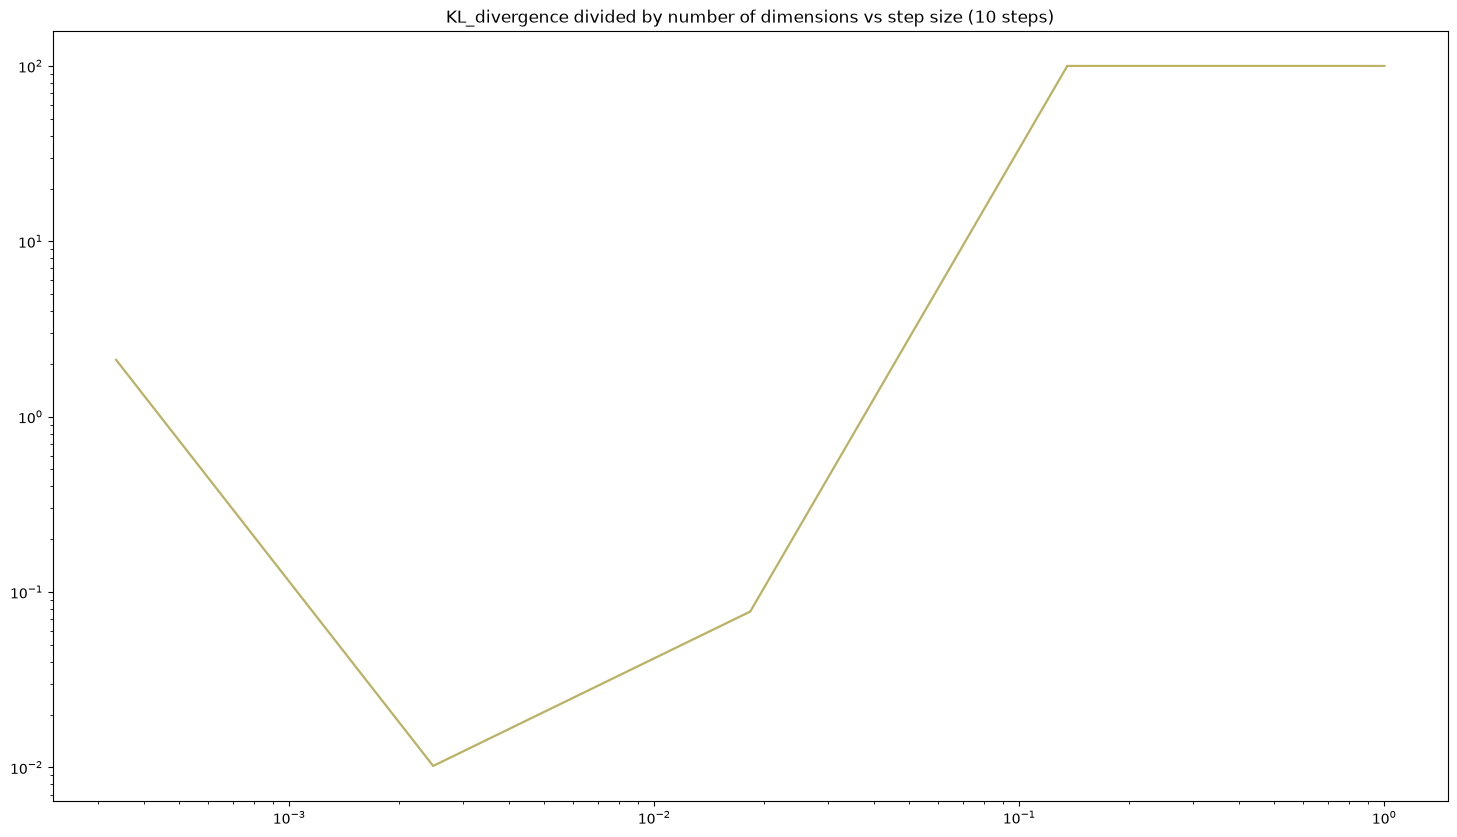

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(18, 10))
axes.plot(step_sizes, KL_div_arr/num_dimensions, color = "teal", alpha = 0.5)
axes.plot(step_sizes, KL_div_normalized_arr/num_dimensions, color = "orange", alpha = 0.5)
axes.set_xscale("log")
axes.set_yscale("log")
axes.set_title("KL_divergence divided by number of dimensions vs step size (10 steps)")